# **Classification of Claims in TikTok Videos**
**Fifth Stage - Machine Learning Model Development**

**Situatiom:** In this stage we ned to **build a machine learning model that can be used to determine whether a video contains a claim or whether it offers an opinion**. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

# **Classifying videos using machine learning**

In this stage, we will use machine learning techniques to predict on a binary outcome variable.
<br/>

**The purpose** of this model is to increase response time and system efficiency by automating the initial stages of the claims process.

**The goal** of this model is to predict whether a TikTok video presents a "claim" or presents an "opinion".
<br/>

*This stage has three parts:*

**Part 1:** Ethical considerations
* Considering the ethical implications of the request

**Part 2:** Feature engineering

* Performing feature selection, extraction, and transformation to prepare the data for modeling

**Part 3:** Modeling

* Building the models, evaluating them, and advising on next steps



# **Classifying videos using machine learning**

# **PACE stages**


## **PACE: Plan**


In this stage:

1. I've been asked to develop a classification machine learning model that is able to predict wether a given video is a claim or an opinion.
2. The errors made by the model differe in there impact. false positive error will deacrese author satisfaction because their opinions as cosidered as claims and therefore they might leave the platform. While false negative errors will deacrese viewer trust in the videos uploaded by authors, and this might lead to customers angery becasue of not considering their reports. in my opinion type I error is worse.
3. I recommand developing a model that predicts wether a video `might_be_claim` and them letting tiktok team review videos with value of 1.

**Modeling workflow and model selection process**

Previous work with this data has revealed that there are ~20,000 videos in the sample. This is sufficient to conduct a rigorous model validation workflow, broken into the following steps:

1. Splitting the data into train/validation/test sets (60/20/20)
2. Fitting models and tune hyperparameters on the training set
3. Performing final model selection on the validation set
4. Assessing the champion model's performance on the test set


### **Part 1. Imports and data loading**

We'll start by importing packages needed to build machine learning models to achieve the goal of this project.

In [ ]:
# Importing packages for data manipulation
import pandas as pd
import numpy as np
# Importing packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Importing packages for data preprocessing
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split, PredefinedSplit, GridSearchCV

# Importing packages for data modeling
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Loading dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv", index_col=0)

## **PACE: Analyze**`

### **Part 2: Examining data, summary info, and descriptive stats**

In [ ]:
# Displaying first few rows
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [ ]:
# Getting number of rows and columns
data.shape

(19382, 12)

In [ ]:
# Getting basic information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [ ]:
# Generating basic descriptive stats
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [ ]:
# Checking for missing values
data.isna().sum()

claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [ ]:
# Dropping rows with missing values
data = data.dropna(axis=0).reset_index(drop='True')

In [ ]:

# Displaying first few rows after handling missing values
data.head()

,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [ ]:
# Checking for duplicates
data = data.drop_duplicates()

Checking for and handling outliers.

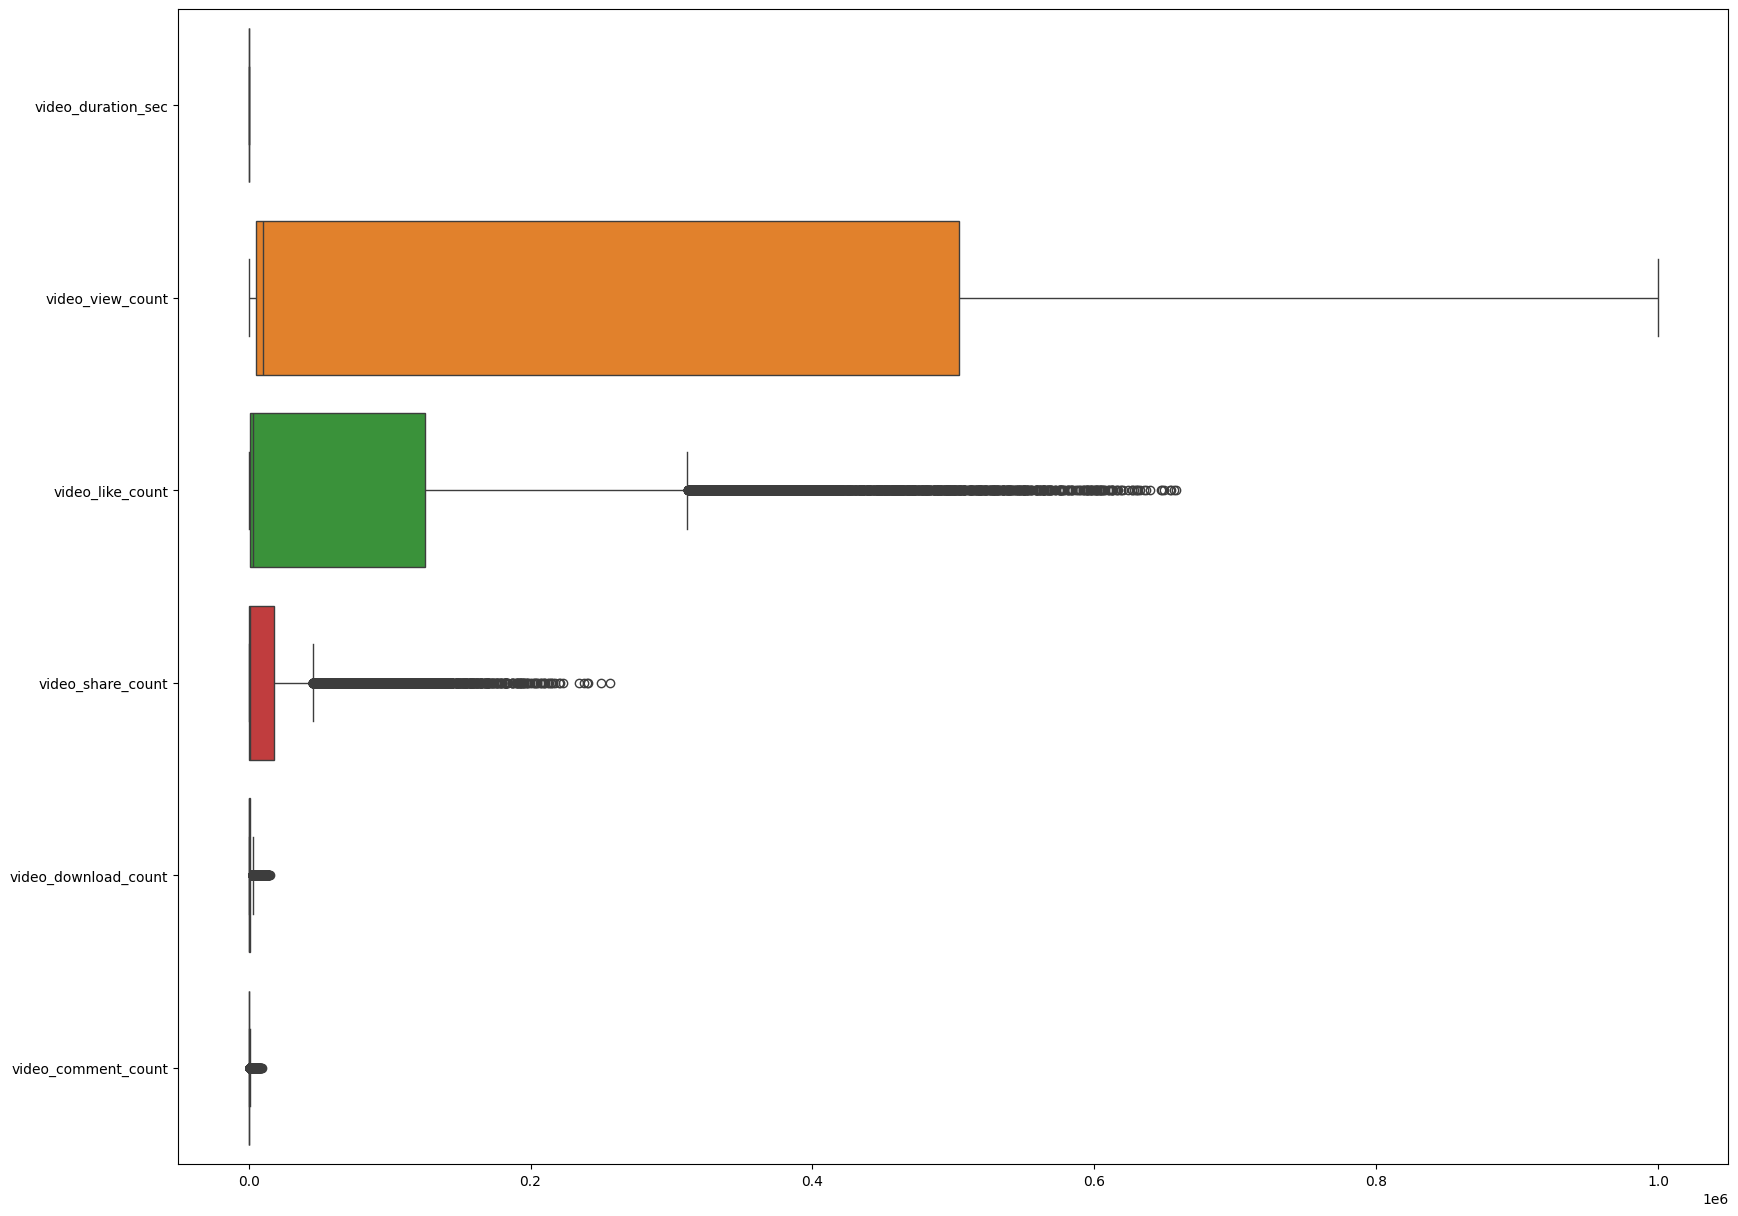

In [ ]:
plt.figure(figsize=(20,15))
sns.boxplot(data = data.drop('video_id',axis=1), orient='h')
plt.show()

In [ ]:
# Checking class balance
data['claim_status'].value_counts(normalize=True)

claim_status
claim      0.503458
opinion    0.496542
Name: proportion, dtype: float64

## **PACE: Construct**

### **Part 3: Feature engineering**

Let's extract the length of each `video_transcription_text` and add this as a column to the dataframe, so that it can be used as a potential feature in the model.

In [ ]:
data['txt_length'] = data['video_transcription_text'].str.len()

In [ ]:
# Calculating the average text_length for claims and opinions
data.groupby('claim_status')['txt_length'].mean()

claim_status
claim      95.376978
opinion    82.722562
Name: txt_length, dtype: float64

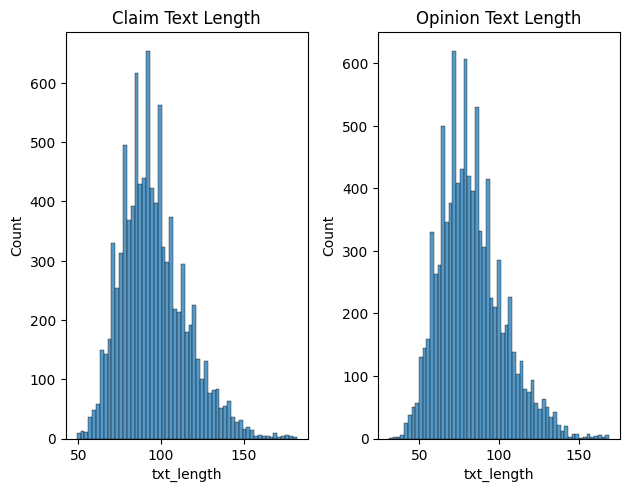

In [ ]:
# Visualizing the distribution of `text_length` for claims and opinions
# Creating two histograms in one plot
fig, axes = plt.subplots(1,2)
sns.histplot(data=data[data['claim_status']=='claim']['txt_length'], ax = axes[0])
sns.histplot(data=data[data['claim_status']=='opinion']['txt_length'], ax = axes[1])
plt.tight_layout()
axes[0].set_title('Claim Text Length')
axes[1].set_title('Opinion Text Length')

plt.show()

**Feature selection and transformation**

Encoding target and catgorical variables.

In [ ]:
# Creating a copy of the X data
df = data.copy()
# Dropping unnecessary columns
df = df.drop(columns=['video_id', 'video_transcription_text'], axis=1)
# Encoding target variable
df['claim_status'] = np.where(df['claim_status']=='claim',1,0)
# Dummy encoding remaining categorical values
df = pd.get_dummies(df, columns=['verified_status','author_ban_status'], drop_first=True, dtype=int)

### **Part 4: Split the data**

In [ ]:
# Isolating target variable
y = df['claim_status']

In [ ]:
# Isolating features
x = df.drop('claim_status', axis=1)
# Displaying first few rows of features dataframe
x.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,txt_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,59,343296.0,19425.0,241.0,1.0,0.0,97,0,0,1
1,32,140877.0,77355.0,19034.0,1161.0,684.0,107,0,0,0
2,31,902185.0,97690.0,2858.0,833.0,329.0,137,0,0,0
3,25,437506.0,239954.0,34812.0,1234.0,584.0,131,0,0,0
4,19,56167.0,34987.0,4110.0,547.0,152.0,128,0,0,0


#### **Part 5: Creating train/validate/test sets**

In [ ]:
# Splitting the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x,y, stratify=y, test_size=0.2,random_state=42)

Splitting the training set into training and validation sets, 75/25, to result in a final ratio of 60/20/20 for train/validate/test sets.

In [ ]:
x_tr, x_val, y_tr, y_val = train_test_split(x_train,y_train, test_size=0.25, stratify=y_train,random_state=42)

Confirming that the dimensions of the training, validation, and testing sets are in alignment.

In [ ]:
print(x_tr.shape, x_val.shape, x_test.shape, y_tr.shape, y_val.shape, y_test.shape)

(11450, 10) (3817, 10) (3817, 10) (11450,) (3817,) (3817,)


### **Part 6. Building models**


### **Building a random forest model**

Fitting a random forest model to the training set using cross-validation to tune the hyperparameters and select the model that performs best on recall.

In [ ]:
# Instantiating the random forest classifier
rf = RandomForestClassifier(random_state=42)
# Creating a dictionary of hyperparameters to tune
cv_params = {
    # Number of trees in the forest
    'n_estimators':[75,100,125.200],

    # Maximum number of levels in each tree
    'max_depth': [3,4,5,6],

    # Minimum number of samples required to split an internal node
    'min_samples_split':[15,20,30],

    # Minimum number of samples required to be at a leaf node
    'min_samples_leaf':[4,5],

    # Number of features to consider at every split
    'max_features': ['sqrt'],}
# Defining a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall','f1']
# Instantiating the GridSearchCV object
rf1 = GridSearchCV(rf, cv_params, cv=5, refit='recall', scoring=scoring)

In [ ]:
# Fitting the model to the data
rf1.fit(x_tr, y_tr)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [3, 4, 5, 6], 'max_features': ['sqrt'],
                         'min_samples_leaf': [4, 5],
                         'min_samples_split': [15, 20, 30],
                         'n_estimators': [75, 100, 125.2]},
             refit='f1', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [ ]:
# Examining best recall score
rf1.best_score_

0.9944150329814926

In [ ]:
# Examining best parameters
rf1.best_params_

{'max_depth': 3,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'min_samples_split': 15,
 'n_estimators': 75}

We need to check the precision score to make sure the model isn't labeling everything as claims. We can do this by using the `cv_results_` attribute of the fit `GridSearchCV` object, which returns a numpy array that can be converted to a pandas dataframe. Then, we need to examine the `mean_test_precision` column of this dataframe at the index containing the results from the best model. This index can be accessed by using the `best_index_` attribute of the fit `GridSearchCV` object.

In [ ]:
# Access ingthe GridSearch results and convert it to a pandas df
results = pd.DataFrame(rf1.cv_results_)
# Examining the GridSearch results df at column `mean_test_precision` in the best index
results.loc[rf1.best_index_,'mean_test_recall']

0.9890700286691722

The model performance is totally perfect!

### **Building an XGBoost model**

In [ ]:
# Instantiating the XGBoost classifier
from xgboost import XGBClassifier
xgb = XGBClassifier(objective='binary:logistic')
# Creating a dictionary of hyperparameters to tune
cv_params = {'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]}
# Instantiating the GridSearchCV object
xgb1 = GridSearchCV(xgb, cv_params, cv=5, refit='recall', scoring=scoring)

In [ ]:
# Fitting the model to the data
xgb1.fit(x_tr, y_tr)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [ ]:
# Examining best recall score
xgb1.best_score_

0.9890701792425558

In [ ]:
# Examining best parameters
xgb1.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

In [ ]:
# Accessing the GridSearch results and convert it to a pandas df
results = pd.DataFrame(xgb1.cv_results_)
# Examining the GridSearch results df at column `mean_test_precision` in the best index
results.loc[xgb1.best_index_,'mean_test_precision']

0.9991247981100294

The model performs pretty well on training data!

## **PACE: Execute**

### **Part 7. Evaluating model**

Evaluating models against validation criteria.

#### **Random forest**

In [ ]:
# Using the random forest "best estimator" model to get predictions on the validation set
rf_pred = rf1.predict(x_val)

In [ ]:
# Displaying the predictions on the validation set
rf_pred

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
# Displaying the true labels of the validation set
y_val

7425     1
9498     1
3101     1
10115    0
11807    0
        ..
10260    0
6178     1
5216     1
651      1
5668     1
Name: claim_status, Length: 3817, dtype: int64

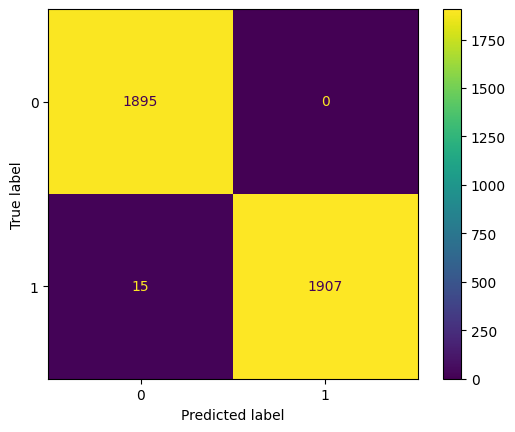

In [ ]:
# Creating a confusion matrix to visualize the results of the classification model

# Computing values for confusion matrix
cm = metrics.confusion_matrix(y_val, rf_pred)
# Creating display of confusion matrix using ConfusionMatrixDisplay()
metrics.ConfusionMatrixDisplay(confusion_matrix =cm, display_labels=rf1.best_estimator_.classes_).plot()
# Displaying plot
plt.show()

In [ ]:
# Creating a classification report
# Creating classification report for random forest model
pd.DataFrame(metrics.classification_report(y_val, rf_pred, output_dict=True)).T.iloc[[1]]

,precision,recall,f1-score,support
1,1.0,0.992196,0.996083,1922.0


These metrics shows that the model performs very well on validation data.

#### **XGBoost**

Now, let's evaluate the XGBoost model on the validation set.

In [ ]:
# Using the best estimator to predict on the validation data
xgb_pred = xgb1.best_estimator_.predict(x_val)

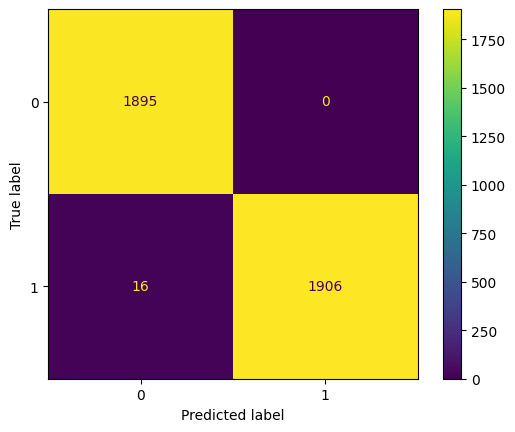

In [ ]:
# Computing values for confusion matrix
cm = metrics.confusion_matrix(y_val, xgb_pred)
# Creating display of confusion matrix using ConfusionMatrixDisplay()
metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb1.best_estimator_.classes_).plot()
# Displaying plot
plt.show()

In [ ]:
# Creating a classification report
pd.DataFrame(metrics.classification_report(y_val, xgb_pred, output_dict=True)).T.iloc[[1]]

,precision,recall,f1-score,support
1,1.0,0.991675,0.99582,1922.0


They perform almost the same, with `random forest` being silghtly better therefore we can consider it as the champion.

### **Using champion model to predict on test data**

In [ ]:
rf_test_pred = rf1.best_estimator_.predict(x_test)

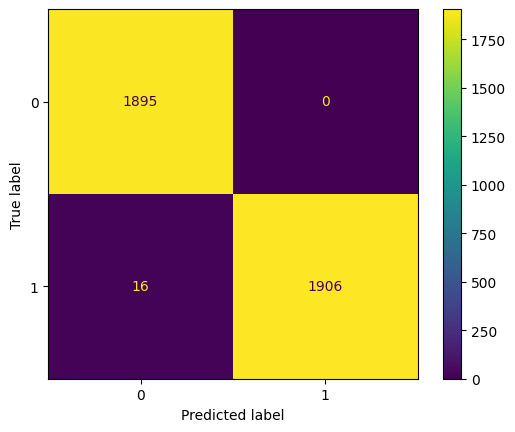

In [ ]:
# Creating a confusion matrix to visualize the results of the classification model

# Computing values for confusion matrix
cm = metrics.confusion_matrix(y_test, rf_test_pred)
# Creating display of confusion matrix using ConfusionMatrixDisplay()
metrics.ConfusionMatrixDisplay(confusion_matrix =cm, display_labels=rf1.best_estimator_.classes_).plot()
# Displaying plot
plt.show()

#### **Feature importances of champion model**


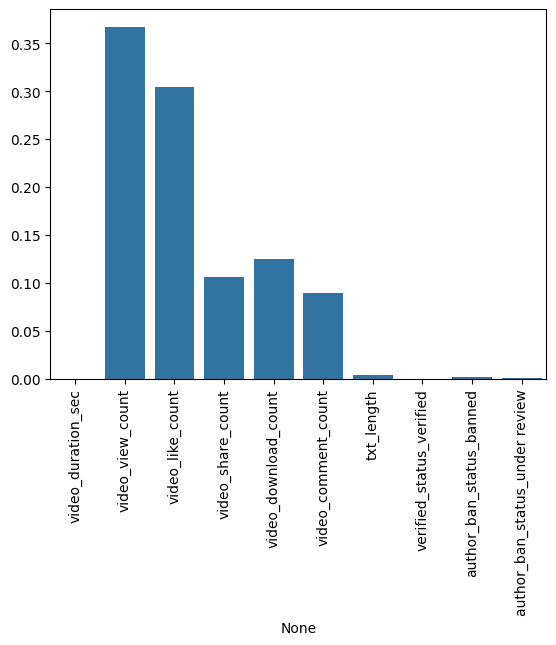

In [ ]:
sns.barplot(y=rf1.best_estimator_.feature_importances_, x=x_train.columns)
plt.xticks(rotation=90)
plt.show()

Most predictive features are video_view_count, video_like_count, video_download_count, video_share_count, and video_comment_count repectively. Which wasn't surprising because we know that claim videos tend to get more interaction.

### **Part 8. Conclusion**

1. It is highly recommanded to start using the model in a free trial because it show good measures and any helpful feedback would be of high benefit.
2. The model is a normal random forest, where each tree predict the result using different features and samples of the data, then their prediction is combined or aggregated into the most probable final prediction.
3. Maybe relation between features for example like_per_view or share_per_view can help us imporve our model further.
4. Getting the number of reports done by the user of the video could be very useful. also number of positive and negative comments for each video. And the genre of the video where some types may tend to include higher claims than others.